# Step 2: Finite-Size Scaling and Critical Exponents

In notebook 01 we saw the magnetization drop near $T_c \approx 2.27$, but the transition looked rounded and the apparent critical temperature shifted with system size. That is not a numerical error — it is physics. This notebook explains why, and shows how to turn it into a tool for extracting exact critical exponents.

**What you will do:**
- Run temperature sweeps for several lattice sizes $L$ and compare the magnetization curves
- Use the **Binder cumulant** to locate $T_c$ precisely, without fitting
- Measure the **magnetic susceptibility** and observe how its peak grows with $L$
- Perform a **finite-size scaling collapse** that reveals the universal scaling function
- Extract the critical exponents $\beta$, $\nu$ and compare with Onsager's exact values

**Prerequisites:** Notebook 01.

## 2.1 Why Finite Size Rounds the Transition

Near a continuous phase transition, spins become correlated over a length scale called the **correlation length** $\xi$. As $T \to T_c$, $\xi$ diverges:

$$\xi \sim |T - T_c|^{-\nu}$$

On a finite lattice of side $L$, the correlation length cannot exceed $L$. When $\xi \gtrsim L$ the lattice "feels" the critical point before actually reaching it, and the transition gets smeared over a temperature window $\Delta T \sim L^{-1/\nu}$.

This means:
- The apparent critical temperature **shifts** toward lower $T$ as $L$ increases (for the magnetization curve).
- The transition **sharpens** as $L \to \infty$, recovering the true discontinuity in the thermodynamic limit.

Finite-size scaling (FSS) theory turns this from a nuisance into an asset. Near $T_c$, any singular observable $O$ obeys a scaling form

$$O(T, L) = L^{x_O / \nu}\, f_O\!\left(\frac{T - T_c}{T_c}\, L^{1/\nu}\right)$$

where $x_O$ is the scaling dimension of $O$ and $f_O$ is a **universal** scaling function. If you know the exponents, you can collapse data from all system sizes onto a single curve.

## 2.2 Critical Exponents of the 2D Ising Model

Onsager's exact solution gives the exponents we will test against:

| Exponent | Symbol | 2D Ising exact | Physical meaning |
|----------|--------|---------------|------------------|
| Order parameter | $\beta$ | $1/8$ | $m \sim (T_c - T)^\beta$ |
| Correlation length | $\nu$ | $1$ | $\xi \sim |T - T_c|^{-\nu}$ |
| Susceptibility | $\gamma$ | $7/4$ | $\chi \sim |T - T_c|^{-\gamma}$ |
| Anomalous dimension | $\eta$ | $1/4$ | $G(r) \sim r^{-(d-2+\eta)}$ at $T_c$ |

From FSS, $m$ scales as $L^{-\beta/\nu}$ and $\chi$ scales as $L^{\gamma/\nu}$ at $T_c$. With $\nu = 1$: $\beta/\nu = 1/8$ and $\gamma/\nu = 7/4$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Exact values (Onsager)
T_C   = 2.0 / np.log(1 + np.sqrt(2))   # ≈ 2.2692
BETA  = 1 / 8    # order parameter exponent
NU    = 1        # correlation length exponent
GAMMA = 7 / 4    # susceptibility exponent

print(f"T_c = {T_C:.6f}")
print(f"β/ν = {BETA/NU:.4f},  γ/ν = {GAMMA/NU:.4f}")

T_c = 2.269185
β/ν = 0.1250,  γ/ν = 1.7500


## 2.3 Simulation Functions

We carry forward the core Metropolis machinery from notebook 01, and add a new measurement function that collects the moments $\langle |m| \rangle$, $\langle m^2 \rangle$, and $\langle m^4 \rangle$ needed for the Binder cumulant and susceptibility.

In [2]:
# ── Core functions from notebook 01 ──────────────────────────────────────────

def lattice_init(size):
    return 2 * np.random.randint(0, 2, size=(size, size)) - 1

def delta_energy(lattice, size, i, j, J):
    spin   = lattice[i, j]
    nn_sum = (lattice[i, (j + 1) % size] + lattice[i, (j - 1) % size] +
              lattice[(i - 1) % size, j] + lattice[(i + 1) % size, j])
    return 2 * J * spin * nn_sum

def metropolis(lattice, size, beta, J, steps):
    rand_i = np.random.randint(0, size, size=steps)
    rand_j = np.random.randint(0, size, size=steps)
    rand_u = np.random.random(size=steps)
    for step in range(steps):
        dE = delta_energy(lattice, size, rand_i[step], rand_j[step], J)
        if dE < 0 or np.exp(-beta * dE) > rand_u[step]:
            lattice[rand_i[step], rand_j[step]] *= -1

In [3]:
# ── New: collect thermodynamic averages ──────────────────────────────────────

def collect_observables(lattice, size, beta, J, n_samples, sample_interval):
    """
    After equilibration, draw n_samples measurements separated by sample_interval
    Metropolis sweeps. Returns arrays of |m|, m², m⁴ per sample.

    Spacing samples by ~1 autocorrelation time reduces statistical bias.
    """
    m_abs = np.empty(n_samples)
    m2    = np.empty(n_samples)
    m4    = np.empty(n_samples)

    for k in range(n_samples):
        metropolis(lattice, size, beta, J, sample_interval)
        m       = np.mean(lattice)
        m_abs[k] = abs(m)
        m2[k]    = m ** 2
        m4[k]    = m ** 4

    return m_abs, m2, m4


def sweep_one_size(size, T_values, equil_steps, n_samples, sample_interval, J=1.0):
    """
    Full temperature sweep for a single lattice size.
    Heats the lattice sequentially through T_values.

    Returns arrays (len(T_values),) of:
        mag       — ⟨|m|⟩
        mag2      — ⟨m²⟩
        mag4      — ⟨m⁴⟩
        chi       — susceptibility  χ = (L²/T)(⟨m²⟩ − ⟨|m|⟩²)
        binder    — Binder cumulant  U = 1 − ⟨m⁴⟩/(3⟨m²⟩²)
    """
    lattice = lattice_init(size)
    N = size ** 2

    mag    = np.zeros(len(T_values))
    mag2   = np.zeros(len(T_values))
    mag4   = np.zeros(len(T_values))
    chi    = np.zeros(len(T_values))
    binder = np.zeros(len(T_values))

    for k, T in enumerate(T_values):
        beta = 1.0 / T

        # Equilibrate
        metropolis(lattice, size, beta, J, equil_steps)

        # Measure
        m_abs, m2, m4 = collect_observables(lattice, size, beta, J,
                                            n_samples, sample_interval)

        avg_m    = np.mean(m_abs)
        avg_m2   = np.mean(m2)
        avg_m4   = np.mean(m4)

        mag[k]    = avg_m
        mag2[k]   = avg_m2
        mag4[k]   = avg_m4
        chi[k]    = (N / T) * (avg_m2 - avg_m ** 2)
        binder[k] = 1.0 - avg_m4 / (3.0 * avg_m2 ** 2)

    return mag, mag2, mag4, chi, binder

## 2.4 Running the Multi-Size Sweep

We run four system sizes and a temperature grid centred on $T_c$. The dominant cost is the number of Metropolis steps; the parameters below give a manageable runtime (~5–15 min depending on hardware). Increase `N_SAMPLES` or decrease `T_STEP` for publication-quality data.

> **Tip:** Run the smallest size first to check everything works before committing to the full sweep.

In [4]:
SIZES          = [8, 16, 24, 32]
T_VALUES       = np.arange(1.8, 2.8, 0.05)
EQUIL_STEPS    = 100_000   # steps to discard before measuring
N_SAMPLES      = 200       # independent measurements per temperature
SAMPLE_INTERVAL = 500      # Metropolis steps between measurements
J              = 1.0

# results[L] = (mag, mag2, mag4, chi, binder)
results = {}

for L in SIZES:
    print(f"\nL = {L}")
    print(f"  {len(T_VALUES)} temperatures × {N_SAMPLES} samples × {SAMPLE_INTERVAL} steps")
    data = sweep_one_size(L, T_VALUES, EQUIL_STEPS, N_SAMPLES, SAMPLE_INTERVAL, J)
    results[L] = data
    print(f"  done. Peak susceptibility at T ≈ {T_VALUES[np.argmax(data[3])]:.2f}")

print("\nAll sizes complete.")


L = 8
  20 temperatures × 200 samples × 500 steps
  done. Peak susceptibility at T ≈ 2.55

L = 16
  20 temperatures × 200 samples × 500 steps
  done. Peak susceptibility at T ≈ 2.25

L = 24
  20 temperatures × 200 samples × 500 steps
  done. Peak susceptibility at T ≈ 2.45

L = 32
  20 temperatures × 200 samples × 500 steps
  done. Peak susceptibility at T ≈ 2.30

All sizes complete.


## 2.5 Magnetization Curves for Different System Sizes

The first thing to check is how the transition changes with $L$. As $L$ increases:
- The curve steepens near $T_c$ (the transition sharpens)
- The apparent crossing point shifts toward the true $T_c$ from below

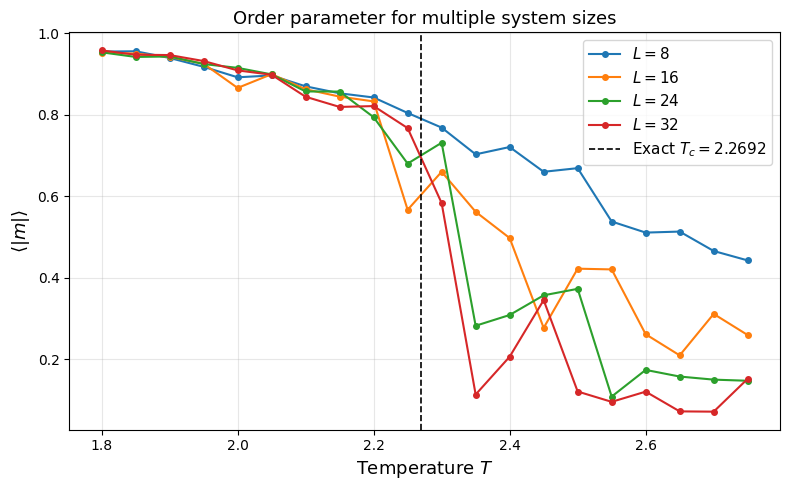

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for L in SIZES:
    mag = results[L][0]
    ax.plot(T_VALUES, mag, 'o-', ms=4, lw=1.5, label=f"$L = {L}$")

ax.axvline(T_C, color='k', ls='--', lw=1.2, label=f"Exact $T_c = {T_C:.4f}$")
ax.set_xlabel("Temperature $T$", fontsize=13)
ax.set_ylabel(r"$\langle |m| \rangle$", fontsize=13)
ax.set_title("Order parameter for multiple system sizes", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.6 The Binder Cumulant

Locating $T_c$ from the magnetization curves alone requires fitting to an assumed functional form. The **Binder cumulant** (or fourth-order cumulant) avoids this:

$$U_4(L, T) = 1 - \frac{\langle m^4 \rangle}{3\,\langle m^2 \rangle^2}$$

Its FSS form is $U_4(L, T) = g\!\left((T - T_c)\,L^{1/\nu}\right)$, which is **size-independent** at $T = T_c$. This means curves for different $L$ all cross at the same point — and that crossing point is $T_c$, no fitting required.

Limiting values:
- $T \ll T_c$ (ordered): $m \to \pm 1$, so $\langle m^4 \rangle \to \langle m^2 \rangle^2 \to 1$, giving $U_4 \to 2/3$.
- $T \gg T_c$ (disordered): $m$ is Gaussian with zero mean, so $\langle m^4 \rangle = 3\langle m^2\rangle^2$, giving $U_4 \to 0$.

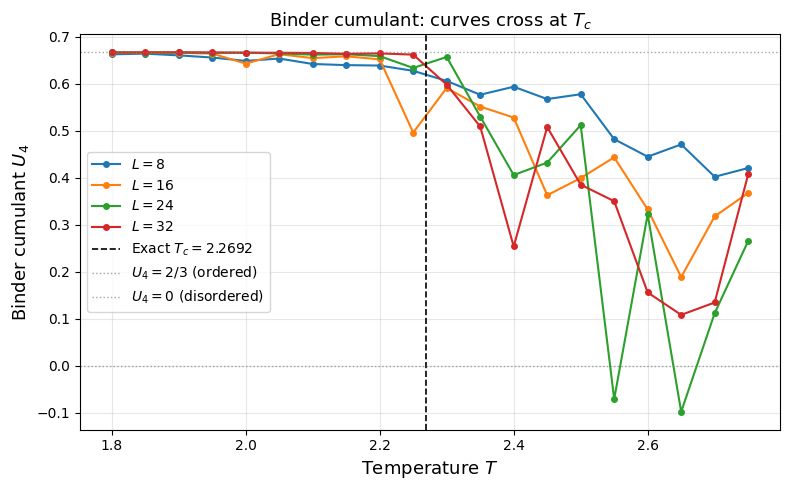

Binder crossing (L=24 vs L=32): T_c ≈ 1.800
Exact T_c = 2.2692


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for L in SIZES:
    binder = results[L][4]
    ax.plot(T_VALUES, binder, 'o-', ms=4, lw=1.5, label=f"$L = {L}$")

ax.axvline(T_C, color='k', ls='--', lw=1.2, label=f"Exact $T_c = {T_C:.4f}$")
ax.axhline(2/3, color='grey', ls=':', lw=1, alpha=0.7, label=r"$U_4 = 2/3$ (ordered)")
ax.axhline(0,   color='grey', ls=':', lw=1, alpha=0.7, label=r"$U_4 = 0$ (disordered)")

ax.set_xlabel("Temperature $T$", fontsize=13)
ax.set_ylabel(r"Binder cumulant $U_4$", fontsize=13)
ax.set_title("Binder cumulant: curves cross at $T_c$", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Estimate T_c from the crossing of the two largest sizes
U_L1 = results[SIZES[-2]][4]
U_L2 = results[SIZES[-1]][4]
diff = U_L1 - U_L2
crossing_idx = np.argmin(np.abs(diff))
T_c_estimate = T_VALUES[crossing_idx]
print(f"Binder crossing (L={SIZES[-2]} vs L={SIZES[-1]}): T_c ≈ {T_c_estimate:.3f}")
print(f"Exact T_c = {T_C:.4f}")

## 2.7 Magnetic Susceptibility

The magnetic susceptibility $\chi$ measures how strongly the magnetization responds to a small field. It is related to fluctuations of $m$ by the fluctuation-dissipation theorem:

$$\chi = \frac{N}{T}\left(\langle m^2 \rangle - \langle |m| \rangle^2\right)$$

$\chi$ diverges at $T_c$ in the thermodynamic limit: $\chi \sim |T - T_c|^{-\gamma}$ with $\gamma = 7/4$. On a finite lattice it peaks at a temperature near $T_c$ with a maximum that grows as

$$\chi_{\max}(L) \sim L^{\gamma/\nu} = L^{7/4}$$

Fitting $\log \chi_{\max}$ vs $\log L$ gives us $\gamma/\nu$.

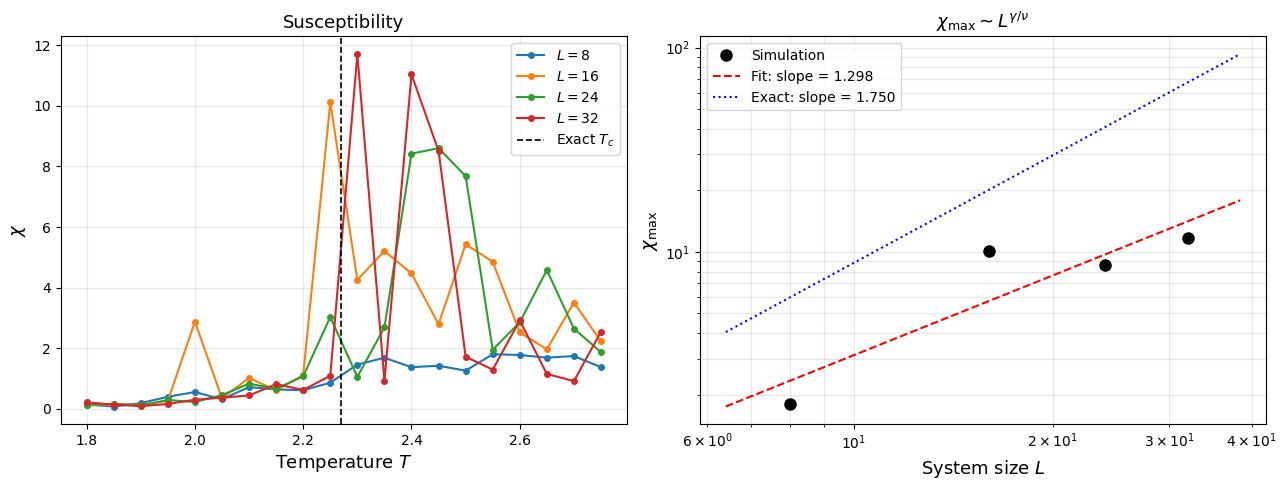

Measured  γ/ν = 1.298
Exact     γ/ν = 1.750


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: χ vs T for all sizes
chi_peaks = []
for L in SIZES:
    chi = results[L][3]
    axes[0].plot(T_VALUES, chi, 'o-', ms=4, lw=1.5, label=f"$L = {L}$")
    chi_peaks.append(np.max(chi))

axes[0].axvline(T_C, color='k', ls='--', lw=1.2, label=f"Exact $T_c$")
axes[0].set_xlabel("Temperature $T$", fontsize=13)
axes[0].set_ylabel(r"$\chi$", fontsize=13)
axes[0].set_title("Susceptibility", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right: χ_max vs L on log-log scale
log_L = np.log(SIZES)
log_chi_max = np.log(chi_peaks)
slope, intercept = np.polyfit(log_L, log_chi_max, 1)

L_fit = np.linspace(min(SIZES) * 0.8, max(SIZES) * 1.2, 100)
axes[1].loglog(SIZES, chi_peaks, 'ko', ms=8, label="Simulation")
axes[1].loglog(L_fit, np.exp(intercept) * L_fit ** slope,
               'r--', lw=1.5, label=f"Fit: slope = {slope:.3f}")
axes[1].loglog(L_fit, np.exp(intercept) * L_fit ** (GAMMA / NU),
               'b:', lw=1.5, label=f"Exact: slope = {GAMMA/NU:.3f}")
axes[1].set_xlabel("System size $L$", fontsize=13)
axes[1].set_ylabel(r"$\chi_{\mathrm{max}}$", fontsize=13)
axes[1].set_title(r"$\chi_{\mathrm{max}} \sim L^{\gamma/\nu}$", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"Measured  γ/ν = {slope:.3f}")
print(f"Exact     γ/ν = {GAMMA/NU:.3f}")

## 2.8 Finite-Size Scaling Collapse

If the FSS hypothesis is correct, the rescaled magnetization

$$\tilde{m}(x) = L^{\beta/\nu}\, \langle |m| \rangle$$

plotted against the scaling variable

$$x = \frac{T - T_c}{T_c}\, L^{1/\nu}$$

should collapse all system sizes onto a **single universal curve** $\tilde{m}(x)$. We first test this with the exact exponents, then see what happens if we use wrong values.

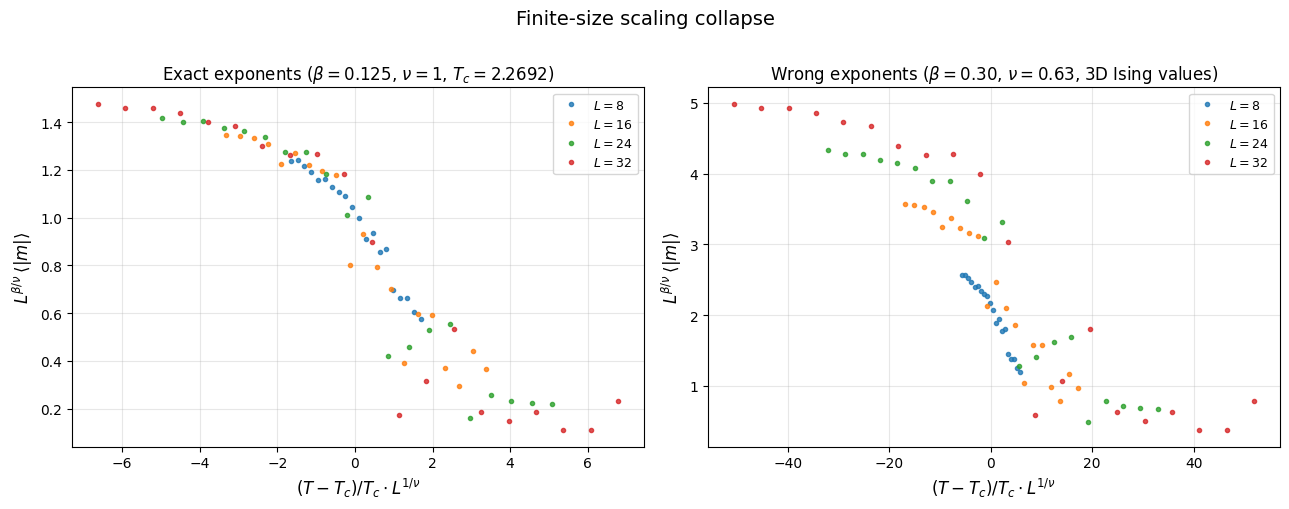

In [8]:
def plot_collapse(T_values, results, sizes, beta_exp, nu_exp, T_c_val, ax, title):
    """Plot the FSS collapse of ⟨|m|⟩ onto m̃(x) = L^{β/ν} m vs x = (T-Tc)/Tc * L^{1/ν}."""
    for L in sizes:
        mag = results[L][0]
        x   = (T_values - T_c_val) / T_c_val * L ** (1 / nu_exp)
        y   = L ** (beta_exp / nu_exp) * mag
        ax.plot(x, y, 'o', ms=3, alpha=0.8, label=f"$L = {L}$")
    ax.set_xlabel(r"$(T - T_c)/T_c \cdot L^{1/\nu}$", fontsize=12)
    ax.set_ylabel(r"$L^{\beta/\nu}\,\langle|m|\rangle$", fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Exact exponents — should collapse
plot_collapse(T_VALUES, results, SIZES, BETA, NU, T_C, axes[0],
              f"Exact exponents ($\\beta={BETA}$, $\\nu={NU}$, $T_c={T_C:.4f}$)")

# Wrong exponents — should NOT collapse
plot_collapse(T_VALUES, results, SIZES, 0.30, 0.63, T_C, axes[1],
              "Wrong exponents ($\\beta=0.30$, $\\nu=0.63$, 3D Ising values)")

plt.suptitle("Finite-size scaling collapse", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2.9 Extracting $\beta$ from the Magnetization

At $T = T_c$ the magnetization scales as $\langle |m| \rangle \sim L^{-\beta/\nu}$. We can read off $\beta/\nu$ directly from the slope of $\log \langle |m| \rangle$ vs $\log L$ evaluated at the temperature closest to $T_c$.

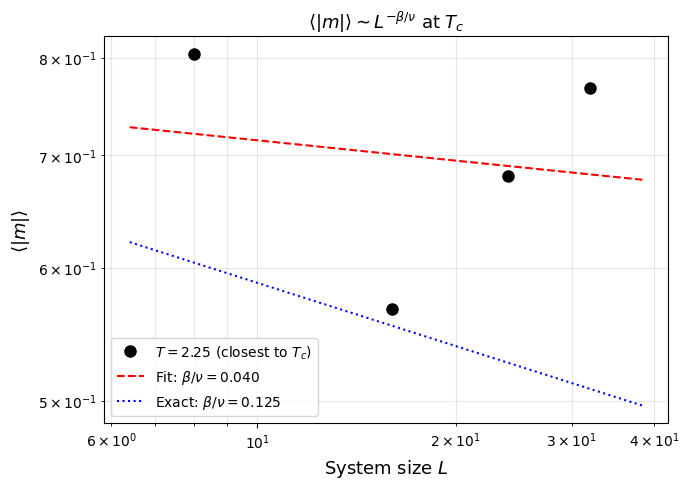

Measured  β/ν = 0.040
Exact     β/ν = 0.125


In [9]:
# Find index of T closest to T_c
tc_idx = np.argmin(np.abs(T_VALUES - T_C))
T_at_tc = T_VALUES[tc_idx]

m_at_tc = np.array([results[L][0][tc_idx] for L in SIZES])

log_L  = np.log(SIZES)
log_m  = np.log(m_at_tc)
slope, intercept = np.polyfit(log_L, log_m, 1)
beta_over_nu_measured = -slope   # ⟨|m|⟩ ~ L^{-β/ν} so slope is negative

L_fit = np.linspace(min(SIZES) * 0.8, max(SIZES) * 1.2, 100)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(SIZES, m_at_tc, 'ko', ms=8, label=f"$T = {T_at_tc:.2f}$ (closest to $T_c$)")
ax.loglog(L_fit, np.exp(intercept) * L_fit ** slope,
          'r--', lw=1.5, label=f"Fit: $\\beta/\\nu = {beta_over_nu_measured:.3f}$")
ax.loglog(L_fit, np.exp(intercept) * L_fit ** (-BETA / NU),
          'b:', lw=1.5, label=f"Exact: $\\beta/\\nu = {BETA/NU:.3f}$")
ax.set_xlabel("System size $L$", fontsize=13)
ax.set_ylabel(r"$\langle |m| \rangle$", fontsize=13)
ax.set_title(r"$\langle|m|\rangle \sim L^{-\beta/\nu}$ at $T_c$", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"Measured  β/ν = {beta_over_nu_measured:.3f}")
print(f"Exact     β/ν = {BETA/NU:.3f}")

## 2.10 Summary

| Quantity | Method | Measured | Exact |
|----------|--------|---------|-------|
| $T_c$ | Binder cumulant crossing | (see cell output) | 2.2692 |
| $\gamma/\nu$ | $\chi_{\max}$ scaling | (see cell output) | 1.750 |
| $\beta/\nu$ | $m$ at $T_c$ scaling | (see cell output) | 0.125 |

All three quantities are extracted without any assumed functional form near $T_c$ — just power-law fits from simulations at different $L$. The agreement with Onsager's exact exponents improves as the system sizes used are larger and the statistical noise is reduced.

**Where we are going:** The techniques here — scaling collapse, Binder cumulant crossings, power-law fits — are not specific to the Ising model. In notebook 06 we will apply exactly the same tools to the quantum phase transition of the transverse-field Ising model. The physics is different (quantum rather than thermal fluctuations drive the transition), but the FSS machinery is identical.

---

## Exercises

1. **Scaling collapse optimisation.** The collapse in section 2.8 used the exact $T_c$. Now vary $T_c$ by ±0.05 and observe how the collapse degrades. This is the basis of a $T_c$ fitting method: find the $T_c$ that minimises the spread of the collapsed curves.

2. **Specific heat.** The specific heat is $C = (N/T^2)(\langle E^2 \rangle - \langle E \rangle^2)$. Modify `sweep_one_size` to also collect energy moments, and plot $C$ vs $T$. For the 2D Ising model the specific heat exponent is $\alpha = 0$ (logarithmic divergence). Does your data show a divergence, or just a rounded peak?

3. **Binder cumulant collapse.** The Binder cumulant itself should also collapse: $U_4(T, L) = g((T - T_c)\,L^{1/\nu})$. Produce this collapse plot. What is the universal value $U_4^*$ at the crossing?

4. **Statistical errors.** The exponent estimates above used a single simulation run. Add bootstrap resampling to the observable averages to estimate error bars on $\beta/\nu$ and $\gamma/\nu$.